<div style="
    background: linear-gradient(135deg, #eef6ff, #f8edff);
    border-left: 8px solid #6c63ff;
    padding: 28px;
    border-radius: 14px;
    text-align: center;
">

# 🛍️ Market Basket Analysis using FP-Growth

### Module 6 — Association Rule Mining

**Prepared by:** Princy Jaat  
**Algorithm:** FP-Growth Algorithm  
**Dataset:** Market Basket Dataset  
**Objective:** Discover frequent product combinations and customer purchasing patterns

</div>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [2]:
transactions = [
    ["Laptop", "Mouse", "Keyboard"],
    ["Phone", "Charger", "Earphones"],
    ["Laptop", "Mouse", "Laptop Bag"],
    ["Phone", "Power Bank", "Charger"],
    ["Laptop", "Keyboard", "Mouse", "Laptop Bag"],
    ["Tablet", "Charger", "Earphones"],
    ["Phone", "Earphones", "Smart Watch"],
    ["Laptop", "Mouse", "USB Drive"],
    ["Tablet", "Keyboard", "Stylus"],
    ["Phone", "Charger", "Power Bank", "Earphones"],
    ["Laptop", "Laptop Bag", "Keyboard"],
    ["Phone", "Smart Watch", "Earphones"],
    ["Tablet", "Stylus", "Charger"],
    ["Laptop", "Mouse", "Keyboard", "USB Drive"],
    ["Phone", "Charger", "Phone Cover"],
    ["Laptop", "Mouse", "Laptop Bag"],
    ["Phone", "Earphones", "Power Bank"],
    ["Tablet", "Charger", "Keyboard"],
    ["Laptop", "Keyboard", "USB Drive"],
    ["Phone", "Charger", "Earphones"],
    ["Laptop", "Mouse", "Keyboard"],
    ["Tablet", "Stylus", "Keyboard"],
    ["Phone", "Power Bank", "Phone Cover"],
    ["Laptop", "Laptop Bag", "Mouse"],
    ["Phone", "Earphones", "Smart Watch"],
    ["Tablet", "Charger", "Stylus"],
    ["Laptop", "Mouse", "USB Drive"],
    ["Phone", "Charger", "Power Bank"],
    ["Laptop", "Keyboard", "Laptop Bag"],
    ["Phone", "Charger", "Earphones", "Power Bank"],
    ["Laptop", "Mouse", "Keyboard", "Laptop Bag"],
    ["Tablet", "Stylus", "Charger"],
    ["Phone", "Phone Cover", "Charger"],
    ["Laptop", "USB Drive", "Mouse"],
    ["Phone", "Earphones", "Smart Watch"]
]

print("Total Transactions:", len(transactions))

transactions[:5]

Total Transactions: 35


[['Laptop', 'Mouse', 'Keyboard'],
 ['Phone', 'Charger', 'Earphones'],
 ['Laptop', 'Mouse', 'Laptop Bag'],
 ['Phone', 'Power Bank', 'Charger'],
 ['Laptop', 'Keyboard', 'Mouse', 'Laptop Bag']]

In [3]:
transaction_df = pd.DataFrame({
    "Transaction_ID": range(1, len(transactions) + 1),
    "Products": [", ".join(items) for items in transactions]
})

transaction_df.head(10)

,Transaction_ID,Products
0,1,"Laptop, Mouse, Keyboard"
1,2,"Phone, Charger, Earphones"
2,3,"Laptop, Mouse, Laptop Bag"
3,4,"Phone, Power Bank, Charger"
4,5,"Laptop, Keyboard, Mouse, Laptop Bag"
5,6,"Tablet, Charger, Earphones"
6,7,"Phone, Earphones, Smart Watch"
7,8,"Laptop, Mouse, USB Drive"
8,9,"Tablet, Keyboard, Stylus"
9,10,"Phone, Charger, Power Bank, Earphones"


In [4]:
print("Dataset Shape:", transaction_df.shape)

print("\nMissing Values:")
print(transaction_df.isnull().sum())

print("\nData Types:")
print(transaction_df.dtypes)

print("\nFirst Five Transactions:")
display(transaction_df.head())

Dataset Shape: (35, 2)

Missing Values:
Transaction_ID    0
Products          0
dtype: int64

Data Types:
Transaction_ID    int64
Products            str
dtype: object

First Five Transactions:


,Transaction_ID,Products
0,1,"Laptop, Mouse, Keyboard"
1,2,"Phone, Charger, Earphones"
2,3,"Laptop, Mouse, Laptop Bag"
3,4,"Phone, Power Bank, Charger"
4,5,"Laptop, Keyboard, Mouse, Laptop Bag"


In [5]:
all_products = [
    product
    for transaction in transactions
    for product in transaction
]

product_frequency = pd.Series(
    all_products
).value_counts()

product_frequency

Laptop         14
Phone          14
Charger        13
Mouse          11
Keyboard       11
Earphones      10
Laptop Bag      7
Tablet          7
Power Bank      6
USB Drive       5
Stylus          5
Smart Watch     4
Phone Cover     3
Name: count, dtype: int64

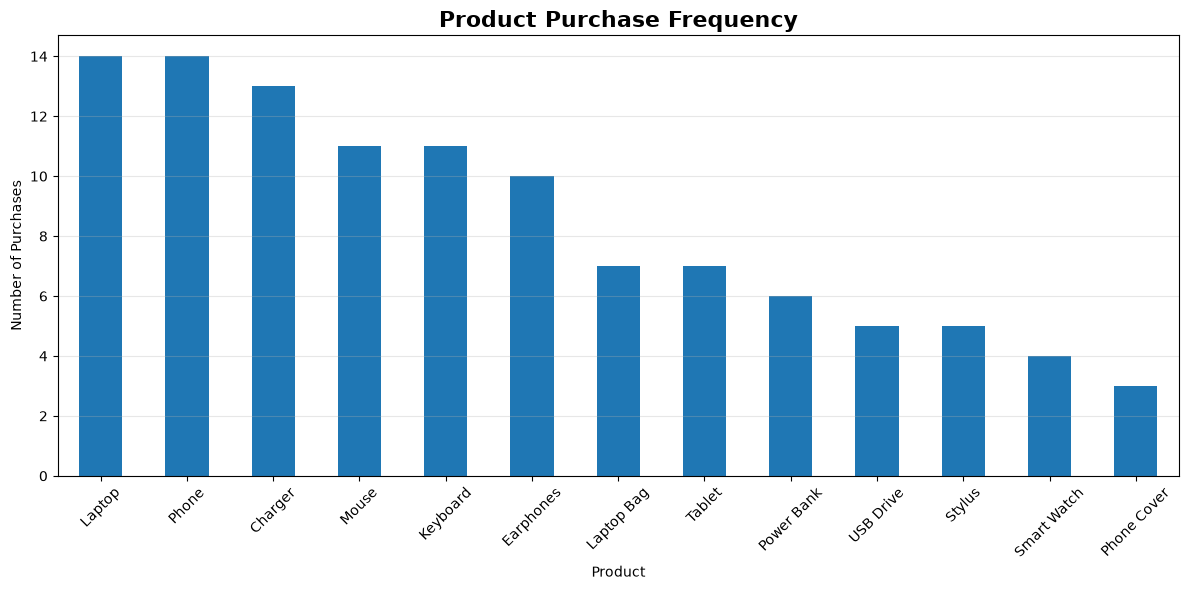

In [6]:
plt.figure(figsize=(12, 6))

product_frequency.plot(kind="bar")

plt.title(
    "Product Purchase Frequency",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Product")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
encoder = TransactionEncoder()

encoded_data = encoder.fit(
    transactions
).transform(transactions)

basket_df = pd.DataFrame(
    encoded_data,
    columns=encoder.columns_
)

basket_df.head()

,Charger,Earphones,Keyboard,Laptop,Laptop Bag,Mouse,Phone,Phone Cover,Power Bank,Smart Watch,Stylus,Tablet,USB Drive
0,False,False,True,True,False,True,False,False,False,False,False,False,False
1,True,True,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,True,True,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,True,False,True,False,False,False,False
4,False,False,True,True,True,True,False,False,False,False,False,False,False


In [8]:
print("Encoded Dataset Shape:", basket_df.shape)

print("\nProduct Columns:")
print(basket_df.columns.tolist())

basket_df.head(10)

Encoded Dataset Shape: (35, 13)

Product Columns:
['Charger', 'Earphones', 'Keyboard', 'Laptop', 'Laptop Bag', 'Mouse', 'Phone', 'Phone Cover', 'Power Bank', 'Smart Watch', 'Stylus', 'Tablet', 'USB Drive']


,Charger,Earphones,Keyboard,Laptop,Laptop Bag,Mouse,Phone,Phone Cover,Power Bank,Smart Watch,Stylus,Tablet,USB Drive
0,False,False,True,True,False,True,False,False,False,False,False,False,False
1,True,True,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,True,True,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,True,False,True,False,False,False,False
4,False,False,True,True,True,True,False,False,False,False,False,False,False
5,True,True,False,False,False,False,False,False,False,False,False,True,False
6,False,True,False,False,False,False,True,False,False,True,False,False,False
7,False,False,False,True,False,True,False,False,False,False,False,False,True
8,False,False,True,False,False,False,False,False,False,False,True,True,False
9,True,True,False,False,False,False,True,False,True,False,False,False,False


In [9]:
frequent_itemsets = fpgrowth(
    basket_df,
    min_support=0.15,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

frequent_itemsets

,support,itemsets
0,0.400000,frozenset({Laptop})
1,0.400000,frozenset({Phone})
2,0.371429,frozenset({Charger})
3,0.314286,frozenset({Mouse})
4,0.314286,frozenset({Keyboard})
5,0.314286,"frozenset({Mouse, Laptop})"
6,0.285714,frozenset({Earphones})
7,0.257143,"frozenset({Phone, Earphones})"
8,0.228571,"frozenset({Charger, Phone})"
9,0.228571,"frozenset({Laptop, Keyboard})"


In [10]:
frequent_itemsets["Itemset_Length"] = (
    frequent_itemsets["itemsets"].apply(len)
)

frequent_itemsets

,support,itemsets,Itemset_Length
0,0.400000,frozenset({Laptop}),1
1,0.400000,frozenset({Phone}),1
2,0.371429,frozenset({Charger}),1
3,0.314286,frozenset({Mouse}),1
4,0.314286,frozenset({Keyboard}),1
5,0.314286,"frozenset({Mouse, Laptop})",2
6,0.285714,frozenset({Earphones}),1
7,0.257143,"frozenset({Phone, Earphones})",2
8,0.228571,"frozenset({Charger, Phone})",2
9,0.228571,"frozenset({Laptop, Keyboard})",2


In [11]:
single_itemsets = frequent_itemsets[
    frequent_itemsets["Itemset_Length"] == 1
]

single_itemsets

,support,itemsets,Itemset_Length
0,0.400000,frozenset({Laptop}),1
1,0.400000,frozenset({Phone}),1
2,0.371429,frozenset({Charger}),1
3,0.314286,frozenset({Mouse}),1
4,0.314286,frozenset({Keyboard}),1
6,0.285714,frozenset({Earphones}),1
10,0.200000,frozenset({Laptop Bag}),1
12,0.200000,frozenset({Tablet}),1
13,0.171429,frozenset({Power Bank}),1


In [12]:
pair_itemsets = frequent_itemsets[
    frequent_itemsets["Itemset_Length"] == 2
]

pair_itemsets

,support,itemsets,Itemset_Length
5,0.314286,"frozenset({Mouse, Laptop})",2
7,0.257143,"frozenset({Phone, Earphones})",2
8,0.228571,"frozenset({Charger, Phone})",2
9,0.228571,"frozenset({Laptop, Keyboard})",2
11,0.200000,"frozenset({Laptop, Laptop Bag})",2
14,0.171429,"frozenset({Power Bank, Phone})",2


In [13]:
triple_itemsets = frequent_itemsets[
    frequent_itemsets["Itemset_Length"] == 3
]

triple_itemsets

,support,itemsets,Itemset_Length


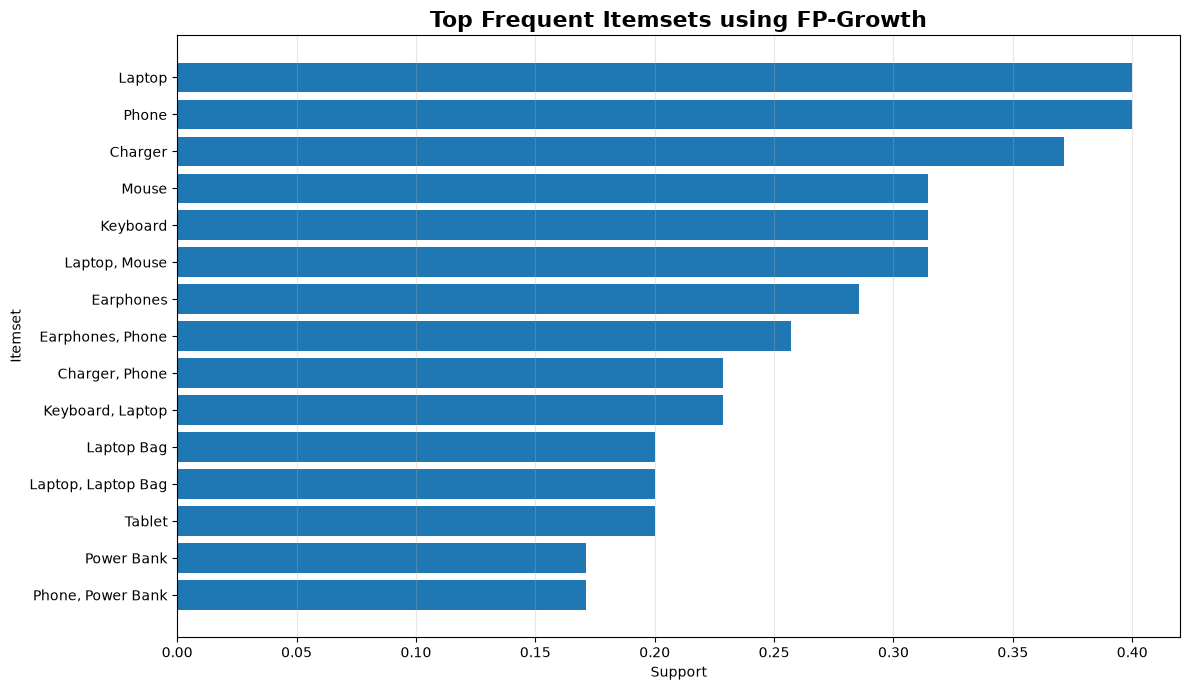

In [14]:
top_itemsets = frequent_itemsets.head(15).copy()

top_itemsets["Itemset"] = top_itemsets[
    "itemsets"
].apply(
    lambda items: ", ".join(sorted(list(items)))
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_itemsets["Itemset"],
    top_itemsets["support"]
)

plt.title(
    "Top Frequent Itemsets using FP-Growth",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.50
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Mouse}),frozenset({Laptop}),0.314286,0.400000,0.314286,1.000000,2.500000,1.0,0.188571,inf,0.875000,0.785714,1.000000,0.892857
1,frozenset({Laptop}),frozenset({Mouse}),0.400000,0.314286,0.314286,0.785714,2.500000,1.0,0.188571,3.20,1.000000,0.785714,0.687500,0.892857
2,frozenset({Phone}),frozenset({Earphones}),0.400000,0.285714,0.257143,0.642857,2.250000,1.0,0.142857,2.00,0.925926,0.600000,0.500000,0.771429
3,frozenset({Earphones}),frozenset({Phone}),0.285714,0.400000,0.257143,0.900000,2.250000,1.0,0.142857,6.00,0.777778,0.600000,0.833333,0.771429
4,frozenset({Charger}),frozenset({Phone}),0.371429,0.400000,0.228571,0.615385,1.538462,1.0,0.080000,1.56,0.556818,0.421053,0.358974,0.593407


In [16]:
rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].copy()

rules = rules.sort_values(
    by="lift",
    ascending=False
).reset_index(drop=True)

rules.head(15)

,antecedents,consequents,support,confidence,lift
0,frozenset({Mouse}),frozenset({Laptop}),0.314286,1.000000,2.500000
1,frozenset({Laptop}),frozenset({Mouse}),0.314286,0.785714,2.500000
2,frozenset({Laptop Bag}),frozenset({Laptop}),0.200000,1.000000,2.500000
3,frozenset({Laptop}),frozenset({Laptop Bag}),0.200000,0.500000,2.500000
4,frozenset({Power Bank}),frozenset({Phone}),0.171429,1.000000,2.500000
5,frozenset({Phone}),frozenset({Earphones}),0.257143,0.642857,2.250000
6,frozenset({Earphones}),frozenset({Phone}),0.257143,0.900000,2.250000
7,frozenset({Laptop}),frozenset({Keyboard}),0.228571,0.571429,1.818182
8,frozenset({Keyboard}),frozenset({Laptop}),0.228571,0.727273,1.818182
9,frozenset({Phone}),frozenset({Charger}),0.228571,0.571429,1.538462


In [17]:
rules["antecedents"] = rules[
    "antecedents"
].apply(
    lambda items: ", ".join(sorted(list(items)))
)

rules["consequents"] = rules[
    "consequents"
].apply(
    lambda items: ", ".join(sorted(list(items)))
)

rules.head(15)

,antecedents,consequents,support,confidence,lift
0,Mouse,Laptop,0.314286,1.000000,2.500000
1,Laptop,Mouse,0.314286,0.785714,2.500000
2,Laptop Bag,Laptop,0.200000,1.000000,2.500000
3,Laptop,Laptop Bag,0.200000,0.500000,2.500000
4,Power Bank,Phone,0.171429,1.000000,2.500000
5,Phone,Earphones,0.257143,0.642857,2.250000
6,Earphones,Phone,0.257143,0.900000,2.250000
7,Laptop,Keyboard,0.228571,0.571429,1.818182
8,Keyboard,Laptop,0.228571,0.727273,1.818182
9,Phone,Charger,0.228571,0.571429,1.538462


In [18]:
rules["support"] = rules["support"].round(3)
rules["confidence"] = rules["confidence"].round(3)
rules["lift"] = rules["lift"].round(3)

rules.head(15)

,antecedents,consequents,support,confidence,lift
0,Mouse,Laptop,0.314,1.000,2.500
1,Laptop,Mouse,0.314,0.786,2.500
2,Laptop Bag,Laptop,0.200,1.000,2.500
3,Laptop,Laptop Bag,0.200,0.500,2.500
4,Power Bank,Phone,0.171,1.000,2.500
5,Phone,Earphones,0.257,0.643,2.250
6,Earphones,Phone,0.257,0.900,2.250
7,Laptop,Keyboard,0.229,0.571,1.818
8,Keyboard,Laptop,0.229,0.727,1.818
9,Phone,Charger,0.229,0.571,1.538


In [19]:
strong_rules = rules[
    (rules["confidence"] >= 0.60) &
    (rules["lift"] > 1.0)
].copy()

strong_rules = strong_rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

strong_rules

,antecedents,consequents,support,confidence,lift
0,Mouse,Laptop,0.314,1.000,2.500
1,Laptop Bag,Laptop,0.200,1.000,2.500
2,Power Bank,Phone,0.171,1.000,2.500
3,Laptop,Mouse,0.314,0.786,2.500
4,Earphones,Phone,0.257,0.900,2.250
5,Phone,Earphones,0.257,0.643,2.250
6,Keyboard,Laptop,0.229,0.727,1.818
7,Charger,Phone,0.229,0.615,1.538


In [20]:
print("FP-Growth Evaluation Summary")
print("-" * 40)

print("Total Frequent Itemsets:", len(frequent_itemsets))
print("Total Association Rules:", len(rules))
print("Strong Association Rules:", len(strong_rules))

FP-Growth Evaluation Summary
----------------------------------------
Total Frequent Itemsets: 15
Total Association Rules: 11
Strong Association Rules: 8


In [21]:
top_support_rules = rules.sort_values(
    by="support",
    ascending=False
).head(10)

top_support_rules

,antecedents,consequents,support,confidence,lift
0,Mouse,Laptop,0.314,1.000,2.500
1,Laptop,Mouse,0.314,0.786,2.500
6,Earphones,Phone,0.257,0.900,2.250
5,Phone,Earphones,0.257,0.643,2.250
9,Phone,Charger,0.229,0.571,1.538
8,Keyboard,Laptop,0.229,0.727,1.818
7,Laptop,Keyboard,0.229,0.571,1.818
10,Charger,Phone,0.229,0.615,1.538
2,Laptop Bag,Laptop,0.200,1.000,2.500
3,Laptop,Laptop Bag,0.200,0.500,2.500


In [22]:
top_confidence_rules = rules.sort_values(
    by="confidence",
    ascending=False
).head(10)

top_confidence_rules

,antecedents,consequents,support,confidence,lift
0,Mouse,Laptop,0.314,1.000,2.500
2,Laptop Bag,Laptop,0.200,1.000,2.500
4,Power Bank,Phone,0.171,1.000,2.500
6,Earphones,Phone,0.257,0.900,2.250
1,Laptop,Mouse,0.314,0.786,2.500
8,Keyboard,Laptop,0.229,0.727,1.818
5,Phone,Earphones,0.257,0.643,2.250
10,Charger,Phone,0.229,0.615,1.538
7,Laptop,Keyboard,0.229,0.571,1.818
9,Phone,Charger,0.229,0.571,1.538


In [23]:
top_lift_rules = rules.sort_values(
    by="lift",
    ascending=False
).head(10)

top_lift_rules

,antecedents,consequents,support,confidence,lift
0,Mouse,Laptop,0.314,1.000,2.500
1,Laptop,Mouse,0.314,0.786,2.500
2,Laptop Bag,Laptop,0.200,1.000,2.500
3,Laptop,Laptop Bag,0.200,0.500,2.500
4,Power Bank,Phone,0.171,1.000,2.500
5,Phone,Earphones,0.257,0.643,2.250
6,Earphones,Phone,0.257,0.900,2.250
7,Laptop,Keyboard,0.229,0.571,1.818
8,Keyboard,Laptop,0.229,0.727,1.818
9,Phone,Charger,0.229,0.571,1.538


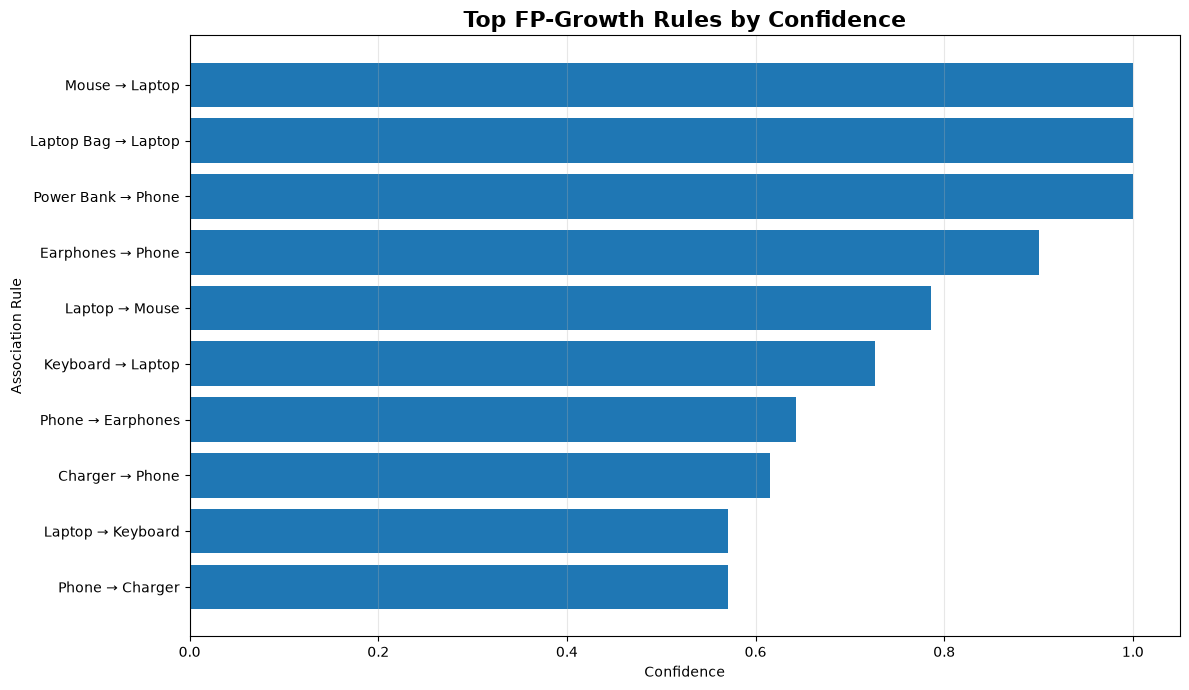

In [24]:
confidence_plot = top_confidence_rules.copy()

confidence_plot["Rule"] = (
    confidence_plot["antecedents"]
    + " → "
    + confidence_plot["consequents"]
)

plt.figure(figsize=(12, 7))

plt.barh(
    confidence_plot["Rule"],
    confidence_plot["confidence"]
)

plt.title(
    "Top FP-Growth Rules by Confidence",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Confidence")
plt.ylabel("Association Rule")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

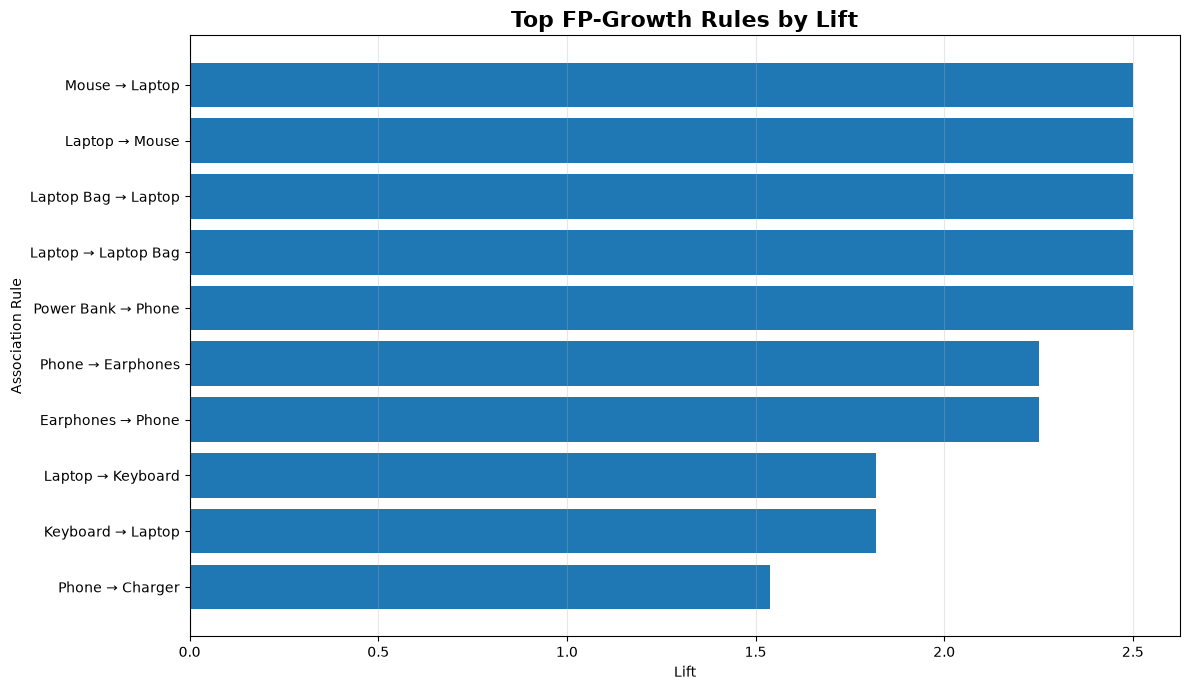

In [25]:
lift_plot = top_lift_rules.copy()

lift_plot["Rule"] = (
    lift_plot["antecedents"]
    + " → "
    + lift_plot["consequents"]
)

plt.figure(figsize=(12, 7))

plt.barh(
    lift_plot["Rule"],
    lift_plot["lift"]
)

plt.title(
    "Top FP-Growth Rules by Lift",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

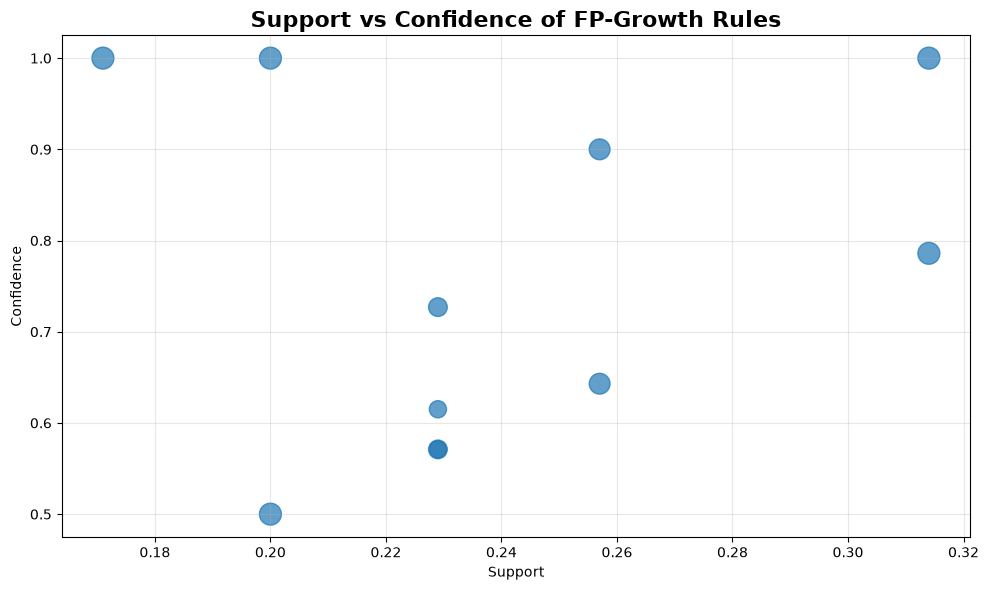

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rules["support"],
    rules["confidence"],
    s=rules["lift"] * 100,
    alpha=0.7
)

plt.title(
    "Support vs Confidence of FP-Growth Rules",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

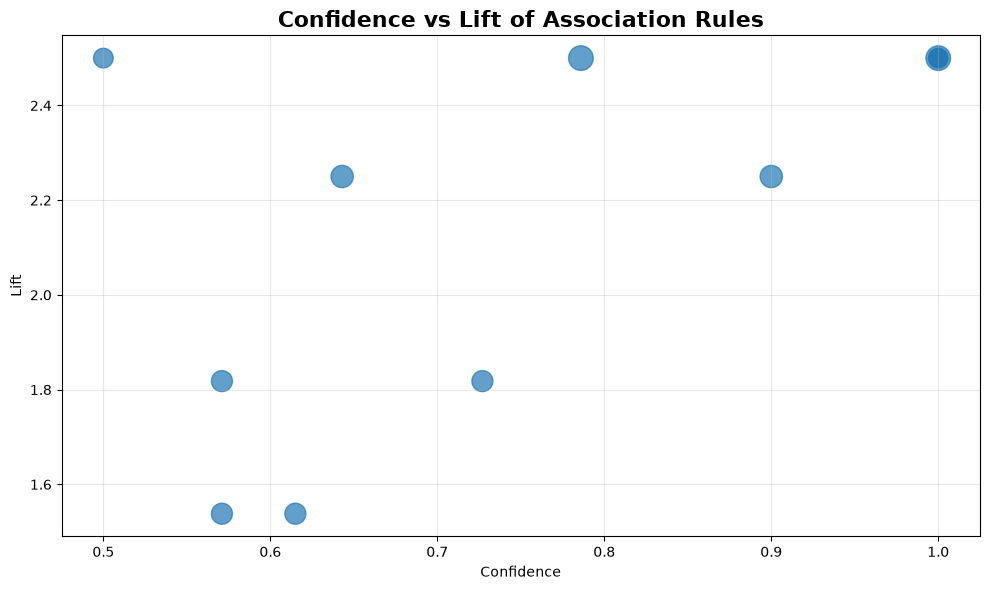

In [27]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rules["confidence"],
    rules["lift"],
    s=rules["support"] * 1000,
    alpha=0.7
)

plt.title(
    "Confidence vs Lift of Association Rules",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
if not strong_rules.empty:

    best_rule = strong_rules.iloc[0]

    print("Best FP-Growth Association Rule")
    print("-" * 45)

    print("If a customer buys:")
    print(best_rule["antecedents"])

    print("\nThe customer may also buy:")
    print(best_rule["consequents"])

    print("\nSupport:", best_rule["support"])
    print("Confidence:", best_rule["confidence"])
    print("Lift:", best_rule["lift"])

else:
    print("No strong association rule found.")

Best FP-Growth Association Rule
---------------------------------------------
If a customer buys:
Mouse

The customer may also buy:
Laptop

Support: 0.314
Confidence: 1.0
Lift: 2.5


In [29]:
for index, row in strong_rules.head(10).iterrows():

    print(
        f"Rule {index + 1}: "
        f"If a customer buys [{row['antecedents']}], "
        f"they may also purchase [{row['consequents']}]."
    )

    print(
        f"Support = {row['support']}, "
        f"Confidence = {row['confidence']}, "
        f"Lift = {row['lift']}"
    )

    print("-" * 75)

Rule 1: If a customer buys [Mouse], they may also purchase [Laptop].
Support = 0.314, Confidence = 1.0, Lift = 2.5
---------------------------------------------------------------------------
Rule 2: If a customer buys [Laptop Bag], they may also purchase [Laptop].
Support = 0.2, Confidence = 1.0, Lift = 2.5
---------------------------------------------------------------------------
Rule 3: If a customer buys [Power Bank], they may also purchase [Phone].
Support = 0.171, Confidence = 1.0, Lift = 2.5
---------------------------------------------------------------------------
Rule 4: If a customer buys [Laptop], they may also purchase [Mouse].
Support = 0.314, Confidence = 0.786, Lift = 2.5
---------------------------------------------------------------------------
Rule 5: If a customer buys [Earphones], they may also purchase [Phone].
Support = 0.257, Confidence = 0.9, Lift = 2.25
---------------------------------------------------------------------------
Rule 6: If a customer buys [Phon

In [30]:
frequent_itemsets_export = frequent_itemsets.copy()

frequent_itemsets_export["itemsets"] = (
    frequent_itemsets_export["itemsets"]
    .apply(
        lambda items: ", ".join(sorted(list(items)))
    )
)

frequent_itemsets_export.to_csv(
    "fp_growth_frequent_itemsets.csv",
    index=False
)

rules.to_csv(
    "fp_growth_association_rules.csv",
    index=False
)

print("Files saved successfully:")
print("1. fp_growth_frequent_itemsets.csv")
print("2. fp_growth_association_rules.csv")

Files saved successfully:
1. fp_growth_frequent_itemsets.csv
2. fp_growth_association_rules.csv


<div style="
    background: linear-gradient(135deg, #edfff3, #eef4ff);
    border-left: 8px solid #2e9d62;
    padding: 25px;
    border-radius: 14px;
">

## ✅ Conclusion

In this notebook, we successfully implemented the **FP-Growth Algorithm** using a Market Basket Dataset.

The algorithm was used to:

- Convert transactions into encoded basket format
- Identify frequently purchased products
- Generate frequent itemsets
- Generate association rules
- Analyse support, confidence and lift
- Filter strong product relationships
- Visualize important association rules
- Export the generated results into CSV files

### Evaluation Interpretation

- **Support** represents how frequently an itemset appears in the complete dataset.
- **Confidence** represents the probability of purchasing the consequent when the antecedent is purchased.
- **Lift** measures the strength of association between the antecedent and consequent.

A lift value greater than `1` represents a positive product association.

FP-Growth is more efficient than Apriori for larger transaction datasets because it generates frequent itemsets without repeatedly creating candidate itemsets.

The generated association rules can help businesses improve product recommendations, cross-selling, product placement, bundle offers and promotional strategies.

</div>